In [1]:
# =============================================================================
# CELL 1 — GLOBAL CONFIGURATION
# =============================================================================
from pathlib import Path
import os
import re
import json
import itertools
import traceback
import warnings
import subprocess
import sys
from datetime import datetime

import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# 1) Path to the final AllFive notebook
# -----------------------------------------------------------------------------
# Put this batch notebook next to AllFive.ipynb, or set the full path here.
ALL5_NOTEBOOK_PATH = Path("AllFive.ipynb")
AUTO_FIND_ALL5_NOTEBOOK = True

# -----------------------------------------------------------------------------
# 2) Input base datasets
# -----------------------------------------------------------------------------
# Recommended: explicitly list the 5 base datasets here.
RAW_DATASET_FILES = [
    # EDIT THESE 5 PATHS:
    # "output/single_datasets_report_only/Pre_M1.csv",
    # "output/single_datasets_report_only/Post1_M1.csv",
    # "output/single_datasets_report_only/Post2_M1.csv",
    # "output/single_datasets_report_only/ADC_M1.csv",
    # "output/single_datasets_report_only/T2_M1.csv",
]

# If RAW_DATASET_FILES is empty, auto-discover CSVs from this folder.
AUTO_DISCOVER_DATASETS = True
SOURCE_DATASET_DIR = Path("../Dataset/Breast-Data/Mask1")
DATASET_GLOB_PATTERN = "*.csv"

# Deterministic modality order used for the output filename and feature prefixes.
PREFERRED_DATASET_ORDER = ["Pre", "Post1", "Post2", "ADC", "T2"]

# Five datasets produce C(5, 5) = 1 all-five combination.
REQUIRE_EXACTLY_FIVE_DATASETS = True

# -----------------------------------------------------------------------------
# 3) Column names and alignment policy
# -----------------------------------------------------------------------------
LABEL_COL = "Label"
GROUP_COL = "PatientID"

ROI_CANDIDATE_COLUMNS = [
    "INFO_NameOfRoi",
    "NameOfRoi",
    "ROI",
    "ROI_Name",
    "LesionID",
    "Lesion_ID",
]

# The first key set that exists and is unique in all five datasets is used.
MERGE_KEY_PRIORITY = [
    ["INFO_NameOfRoi"],
    ["PatientID", "INFO_NameOfRoi"],
    ["LesionID"],
    ["Lesion_ID"],
    ["ROI_Name"],
]

# Row-order fallback is used only when all five row counts and PatientID orders match.
ALLOW_ROW_ORDER_FALLBACK = True
MERGE_HOW = "inner"

# -----------------------------------------------------------------------------
# 4) Output locations
# -----------------------------------------------------------------------------
ALL5_DATASET_DIR = Path("output/all_5_concat_datasets")
BATCH_ROOT = Path("nested_cv_outputs_all_5_concat_batch_smote_compare")
BATCH_RUN_ROOT = Path("batch_all_5_concat_runner_artifacts_smote_compare")

EXECUTED_NOTEBOOK_DIR = BATCH_RUN_ROOT / "executed_all5_notebooks"
MISMATCH_REPORT_DIR = BATCH_RUN_ROOT / "label_group_mismatch_reports"
SUMMARY_DIR = BATCH_RUN_ROOT / "summary_tables"

for p in [ALL5_DATASET_DIR, BATCH_ROOT, BATCH_RUN_ROOT, EXECUTED_NOTEBOOK_DIR, MISMATCH_REPORT_DIR, SUMMARY_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# 5) Notebook execution options
# -----------------------------------------------------------------------------
EXECUTE_ALL5_NOTEBOOKS = True
SKIP_EXISTING_SUCCESSFUL_RUNS = False
OVERWRITE_FS_RUNS = True
COMPARE_SMOTE_OPTIONS = True
RUN_SMOTE_ABLATION = False
RUN_SMOTE_VS_BASELINE_COMPARISON = False
KERNEL_NAME = "python3"
NOTEBOOK_TIMEOUT_SECONDS = None

ADD_PARAMETERS_TAG_TO_ALL5 = True
PATCH_FINAL_ZIP_OUTPUT_IN_PLACE = True

print("Configuration loaded.")
print(f"ALL5_DATASET_DIR: {ALL5_DATASET_DIR.resolve()}")
print(f"BATCH_ROOT:         {BATCH_ROOT.resolve()}")
print(f"SUMMARY_DIR:        {SUMMARY_DIR.resolve()}")

Configuration loaded.
ALL5_DATASET_DIR: /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/All/output/all_5_concat_datasets
BATCH_ROOT:         /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/All/nested_cv_outputs_all_5_concat_batch_smote_compare
SUMMARY_DIR:        /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/All/batch_all_5_concat_runner_artifacts_smote_compare/summary_tables


In [2]:
# =============================================================================
# CELL 2 — ONE-TIME DEPENDENCY CHECK
# =============================================================================

def ensure_import(import_name, pip_name=None):
    import importlib.util
    if importlib.util.find_spec(import_name) is None:
        pip_name = pip_name or import_name
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
    else:
        print(f"OK: {import_name}")

ensure_import("nbformat", "nbformat")
ensure_import("papermill", "papermill")
ensure_import("statsmodels", "statsmodels")
ensure_import("imblearn", "imbalanced-learn")

import nbformat
import papermill as pm

print("Dependency check completed.")

OK: nbformat
OK: papermill
OK: statsmodels
OK: imblearn
Dependency check completed.


In [3]:
# =============================================================================
# CELL 3 — FILE DISCOVERY AND VALIDATION
# =============================================================================

def find_all5_notebook(path: Path) -> Path:
    if path.exists():
        return path.resolve()

    if not AUTO_FIND_ALL5_NOTEBOOK:
        raise FileNotFoundError(f"AllFive notebook not found: {path}")

    candidates = []
    for root in [Path.cwd(), Path("/kaggle/input"), Path("/mnt/data")]:
        if root.exists():
            try:
                candidates.extend(root.rglob(ALL5_NOTEBOOK_PATH.name))
            except Exception:
                pass

    candidates = sorted(set(candidates))
    if len(candidates) == 0:
        raise FileNotFoundError(
            f"Could not find {ALL5_NOTEBOOK_PATH.name}. Put it next to this notebook or set ALL5_NOTEBOOK_PATH."
        )

    print(f"Found {ALL5_NOTEBOOK_PATH.name} candidates:")
    for c in candidates:
        print("  -", c)

    return candidates[0].resolve()


def discover_dataset_files():
    if len(RAW_DATASET_FILES) > 0:
        files = [Path(x) for x in RAW_DATASET_FILES]
    else:
        if not AUTO_DISCOVER_DATASETS:
            raise ValueError("RAW_DATASET_FILES is empty and AUTO_DISCOVER_DATASETS=False.")
        if not SOURCE_DATASET_DIR.exists():
            raise FileNotFoundError(
                f"SOURCE_DATASET_DIR does not exist: {SOURCE_DATASET_DIR}\n"
                "Either create this folder or fill RAW_DATASET_FILES manually."
            )
        files = sorted(SOURCE_DATASET_DIR.glob(DATASET_GLOB_PATTERN))

    filtered = []
    excluded_terms = ["pairwise", "triple", "quad", "all5", "concat", "summary", "comparison", "random_label"]
    for p in files:
        if any(term in p.stem.lower() for term in excluded_terms):
            continue
        filtered.append(p)

    files = [p.resolve() for p in filtered]

    def _ordering_tag(path):
        stem = path.stem
        for suffix in ["_Cleaned", "_cleaned", "_M1"]:
            if stem.endswith(suffix):
                stem = stem[:-len(suffix)]
        return re.sub(r"[^A-Za-z0-9]+", "", stem).lower()

    preferred_rank = {
        re.sub(r"[^A-Za-z0-9]+", "", name).lower(): i
        for i, name in enumerate(PREFERRED_DATASET_ORDER)
    }
    files = sorted(
        files,
        key=lambda p: (preferred_rank.get(_ordering_tag(p), len(preferred_rank)), _ordering_tag(p))
    )

    missing = [str(p) for p in files if not p.exists()]
    if missing:
        raise FileNotFoundError("These dataset files were not found:\n" + "\n".join(missing))

    if REQUIRE_EXACTLY_FIVE_DATASETS and len(files) != 5:
        raise ValueError(
            f"Expected exactly 5 base datasets to create the all-five concat dataset, but found {len(files)}.\n"
            "Files found:\n" + "\n".join(str(p) for p in files) + "\n\n"
            "Fix RAW_DATASET_FILES or SOURCE_DATASET_DIR."
        )

    if len(files) < 5:
        raise ValueError(f"At least 5 base datasets are required; found {len(files)}.")

    return files


ALL5_NOTEBOOK_PATH = find_all5_notebook(ALL5_NOTEBOOK_PATH)
DATASET_FILES = discover_dataset_files()

print("AllFive notebook:")
print(" ", ALL5_NOTEBOOK_PATH)

print("\nBase datasets:")
for i, f in enumerate(DATASET_FILES, start=1):
    print(f"{i}. {f}")

expected_all5s = len(list(itertools.combinations(DATASET_FILES, 5)))
print(f"\nNumber of all-five concat datasets to create: {expected_all5s}")

AllFive notebook:
  /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/All/AllFive.ipynb

Base datasets:
1. /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Dataset/Breast-Data/Mask1/Pre_M1.csv
2. /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Dataset/Breast-Data/Mask1/Post1_M1.csv
3. /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Dataset/Breast-Data/Mask1/Post2_M1.csv
4. /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Dataset/Breast-Data/Mask1/ADC_M1.csv
5. /Users/mahla/MyDriv

In [4]:
# =============================================================================
# CELL 4 — DATASET READING, TAGGING, AND ALL5 CONCAT FUNCTIONS
# =============================================================================

def clean_tag_from_path(path):
    """Create a compact dataset tag from filename."""
    stem = Path(path).stem
    suffixes = [
        "_Cleaned", "_cleaned", "_M1_all5", "_all5",
        "_M1_pairwise", "_pairwise", "_M1"
    ]
    changed = True
    while changed:
        changed = False
        for suffix in suffixes:
            if stem.endswith(suffix):
                stem = stem[:-len(suffix)]
                changed = True
    return re.sub(r"[^A-Za-z0-9]+", "_", stem).strip("_")


def read_csv_flexible(path):
    """Read comma-, semicolon-, tab-, or whitespace-separated CSV robustly."""
    attempts = [
        dict(sep=None, engine="python"),
        dict(sep=","),
        dict(sep=";"),
        dict(sep="\t"),
        dict(sep=r"\s+", engine="python"),
    ]
    last_error = None
    for kwargs in attempts:
        try:
            df = pd.read_csv(path, **kwargs)
            if df.shape[1] > 1:
                return df
        except Exception as exc:
            last_error = exc
    raise RuntimeError(f"Could not read CSV correctly: {path}\nLast error: {last_error}")


def normalize_column_lookup(df):
    return {str(c).strip().lower(): c for c in df.columns}


def resolve_column(df, preferred, candidates=None, required=True, role_name="column"):
    lookup = normalize_column_lookup(df)
    for term in [preferred] + list(candidates or []):
        if term is not None and str(term).strip().lower() in lookup:
            return lookup[str(term).strip().lower()]
    if required:
        raise ValueError(
            f"Could not find required {role_name}. Preferred={preferred}, candidates={candidates}. "
            f"Available columns include: {list(df.columns[:20])}"
        )
    return None


def standardize_label_column(df):
    detected = resolve_column(
        df, LABEL_COL,
        candidates=["label", "Label", "Class", "class", "target", "Target", "diagnosis"],
        required=True, role_name="label column"
    )
    return df.rename(columns={detected: LABEL_COL}) if detected != LABEL_COL else df.copy()


def find_first_existing_column(df, candidates):
    lookup = normalize_column_lookup(df)
    for candidate in candidates:
        key = str(candidate).strip().lower()
        if key in lookup:
            return lookup[key]
    return None


def derive_patient_id(df):
    df = df.copy()
    if GROUP_COL in df.columns and df[GROUP_COL].notna().any():
        source = df[GROUP_COL].astype(str)
    else:
        roi_col = find_first_existing_column(df, ROI_CANDIDATE_COLUMNS)
        patient_col = find_first_existing_column(
            df, ["INFO_PatientName", "PatientName", "patient_name", "SubjectID", "CaseID", "ID"]
        )
        if roi_col is not None:
            source = df[roi_col].astype(str)
        elif patient_col is not None:
            source = df[patient_col].astype(str)
        else:
            raise ValueError(
                "Could not derive PatientID. Provide PatientID, INFO_NameOfRoi, or INFO_PatientName."
            )

    extracted = source.str.extract(r"(P\d+)", expand=False)
    fallback = source.str.replace(r"^[A-Za-z0-9]+_D_", "", regex=True)
    fallback = fallback.str.replace(r"[^A-Za-z0-9]+", "_", regex=True).str.strip("_")
    df[GROUP_COL] = extracted.fillna(fallback).astype(str)
    return df


def preprocess_base_dataset(path):
    df = read_csv_flexible(path).copy()
    empty_cols = df.columns[df.isna().all()].tolist()
    if empty_cols:
        df = df.drop(columns=empty_cols)
    unnamed_cols = [c for c in df.columns if str(c).startswith("Unnamed:")]
    if unnamed_cols:
        df = df.drop(columns=unnamed_cols)
    df = standardize_label_column(df)
    df = derive_patient_id(df)
    return df


def choose_merge_keys_many(datasets):
    """Choose one safe merge key that is present and unique in all five datasets."""
    candidate_sets = list(MERGE_KEY_PRIORITY)
    for roi_col in ROI_CANDIDATE_COLUMNS:
        candidate_sets.append([roi_col])
        candidate_sets.append([GROUP_COL, roi_col])
    candidate_sets.append([GROUP_COL])

    seen = set()
    for keys in candidate_sets:
        keys = [k for k in keys if k is not None]
        key_tuple = tuple(keys)
        if key_tuple in seen:
            continue
        seen.add(key_tuple)
        if all(all(k in df.columns for k in keys) for df in datasets):
            if all(int(df.duplicated(subset=keys).sum()) == 0 for df in datasets):
                return keys, "unique_key"

    if ALLOW_ROW_ORDER_FALLBACK:
        same_length = len({len(df) for df in datasets}) == 1
        if same_length:
            base_order = datasets[0][GROUP_COL].astype(str).reset_index(drop=True)
            same_order = all(
                base_order.equals(df[GROUP_COL].astype(str).reset_index(drop=True))
                for df in datasets[1:]
            )
            if same_order:
                for df in datasets:
                    df["__row_index_all5_key__"] = np.arange(len(df))
                return ["__row_index_all5_key__"], "row_order_fallback"

    raise ValueError(
        "No safe common unique merge key was found across all five datasets. "
        "Use a unique ROI/Lesion column or verify identical PatientID row order."
    )




def prepare_dataset_for_all5_merge(df, tag, keys):
    """Keep shared merge keys; tag every other metadata and feature column."""
    df = df.copy()
    metadata_candidates = [GROUP_COL, LABEL_COL, "INFO_PatientName"] + ROI_CANDIDATE_COLUMNS
    meta_cols = list(keys)
    for col in metadata_candidates:
        if col in df.columns and col not in meta_cols:
            meta_cols.append(col)

    feature_cols = [c for c in df.columns if c not in meta_cols]
    rename_map = {}
    for col in meta_cols:
        if col not in keys:
            rename_map[col] = f"{col}__{tag}"
    for col in feature_cols:
        rename_map[col] = f"{tag}__{col}"

    prepared = df[meta_cols + feature_cols].rename(columns=rename_map)
    tagged_features = [rename_map[c] for c in feature_cols]
    return prepared, tagged_features


def tagged_metadata_column(base_col, tag, keys, merged):
    if base_col in keys and base_col in merged.columns:
        return base_col
    candidate = f"{base_col}__{tag}"
    return candidate if candidate in merged.columns else None


def mismatch_mask_against_first(merged, columns):
    reference = merged[columns[0]].astype(str).str.strip()
    mask = pd.Series(False, index=merged.index)
    for col in columns[1:]:
        mask |= reference.ne(merged[col].astype(str).str.strip())
    return mask


def build_concat_all5_dataset(path_a, path_b, path_c, path_d, path_e):
    paths = [Path(path_a), Path(path_b), Path(path_c), Path(path_d), Path(path_e)]
    tags = [clean_tag_from_path(path) for path in paths]
    all5_tag = "_".join(tags)
    output_path = ALL5_DATASET_DIR / f"{all5_tag}_M1_all5.csv"

    datasets = [preprocess_base_dataset(path) for path in paths]
    keyed_datasets = [df.copy() for df in datasets]
    keys, key_mode = choose_merge_keys_many(keyed_datasets)

    prepared = []
    feature_lists = []
    for df, tag in zip(keyed_datasets, tags):
        pre, features = prepare_dataset_for_all5_merge(df, tag, keys)
        prepared.append(pre)
        feature_lists.append(features)

    merged = prepared[0]
    for next_df in prepared[1:]:
        merged = merged.merge(next_df, on=keys, how=MERGE_HOW, validate="one_to_one")

    if len(merged) == 0:
        raise ValueError(
            f"{all5_tag}: merge produced 0 rows. Check keys={keys} and MERGE_HOW={MERGE_HOW}."
        )

    label_cols = [tagged_metadata_column(LABEL_COL, tag, keys, merged) for tag in tags]
    if any(col is None for col in label_cols):
        raise ValueError(f"{all5_tag}: could not identify all five label columns after merge.")

    label_mismatch = mismatch_mask_against_first(merged, label_cols)
    if label_mismatch.any():
        report_path = MISMATCH_REPORT_DIR / f"{all5_tag}_label_mismatches.csv"
        merged.loc[label_mismatch, keys + label_cols].to_csv(report_path, index=False)
        raise ValueError(
            f"Label mismatch detected for all-five concat {all5_tag}: {int(label_mismatch.sum())} rows. "
            f"Report saved to: {report_path}"
        )

    group_cols = [tagged_metadata_column(GROUP_COL, tag, keys, merged) for tag in tags]
    existing_group_cols = [col for col in group_cols if col is not None]
    if len(existing_group_cols) >= 2:
        group_mismatch = mismatch_mask_against_first(merged, existing_group_cols)
        if group_mismatch.any():
            report_path = MISMATCH_REPORT_DIR / f"{all5_tag}_group_mismatches.csv"
            merged.loc[group_mismatch, keys + existing_group_cols].to_csv(report_path, index=False)
            raise ValueError(
                f"PatientID mismatch detected for all-five concat {all5_tag}: {int(group_mismatch.sum())} rows. "
                f"Report saved to: {report_path}"
            )

    final_df = pd.DataFrame(index=merged.index)
    if existing_group_cols:
        final_df[GROUP_COL] = merged[existing_group_cols[0]].astype(str)
    else:
        final_df[GROUP_COL] = merged[keys[0]].astype(str)

    roi_source = None
    for roi_candidate in ROI_CANDIDATE_COLUMNS:
        if roi_candidate in keys and roi_candidate in merged.columns:
            roi_source = roi_candidate
            break
        candidate = tagged_metadata_column(roi_candidate, tags[0], keys, merged)
        if candidate is not None:
            roi_source = candidate
            break
    if roi_source is not None:
        final_df["INFO_NameOfRoi"] = merged[roi_source].astype(str)

    patient_name_source = tagged_metadata_column("INFO_PatientName", tags[0], keys, merged)
    if patient_name_source is not None:
        final_df["INFO_PatientName"] = merged[patient_name_source].astype(str)

    for feature_list in feature_lists:
        for col in feature_list:
            if col in merged.columns:
                final_df[col] = merged[col]

    final_df[LABEL_COL] = pd.to_numeric(merged[label_cols[0]], errors="raise").astype(int)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    final_df.to_csv(output_path, index=False)

    label_counts = final_df[LABEL_COL].value_counts().sort_index().to_dict()
    numeric_feature_count = len([
        c for c in final_df.select_dtypes(include=[np.number]).columns if c != LABEL_COL
    ])

    meta = {
        "All5_Tag": all5_tag,
        "Dataset_A": tags[0],
        "Dataset_B": tags[1],
        "Dataset_C": tags[2],
        "Dataset_D": tags[3],
        "Dataset_E": tags[4],
        "Dataset_A_Path": str(paths[0]),
        "Dataset_B_Path": str(paths[1]),
        "Dataset_C_Path": str(paths[2]),
        "Dataset_D_Path": str(paths[3]),
        "Dataset_E_Path": str(paths[4]),
        "All5_Input_File": str(output_path.resolve()),
        "Merge_Keys": ",".join(keys),
        "Merge_Key_Mode": key_mode,
        "Merge_How": MERGE_HOW,
        "Rows_A": int(len(datasets[0])),
        "Rows_B": int(len(datasets[1])),
        "Rows_C": int(len(datasets[2])),
        "Rows_D": int(len(datasets[3])),
        "Rows_E": int(len(datasets[4])),
        "Rows_After_Merge": int(len(final_df)),
        "N_Features_A": int(len(feature_lists[0])),
        "N_Features_B": int(len(feature_lists[1])),
        "N_Features_C": int(len(feature_lists[2])),
        "N_Features_D": int(len(feature_lists[3])),
        "N_Features_E": int(len(feature_lists[4])),
        "N_Features_Total": int(numeric_feature_count),
        "Label_Counts": json.dumps({str(k): int(v) for k, v in label_counts.items()}, ensure_ascii=False),
        "Status": "dataset_created",
        "Error": "",
    }
    return output_path.resolve(), meta


In [5]:

# =============================================================================
# CELL 5 — CREATE THE ALL-FIVE CONCAT DATASET
# =============================================================================

all5_dataset_rows = []
all5_dataset_paths = []

for path_a, path_b, path_c, path_d, path_e in itertools.combinations(DATASET_FILES, 5):
    paths = [path_a, path_b, path_c, path_d, path_e]
    tags = [clean_tag_from_path(path) for path in paths]
    all5_tag = "_".join(tags)
    try:
        out_path, meta = build_concat_all5_dataset(path_a, path_b, path_c, path_d, path_e)
        all5_dataset_paths.append(out_path)
        all5_dataset_rows.append(meta)
        print(
            f"✅ Created: {meta['All5_Tag']} | rows={meta['Rows_After_Merge']} | "
            f"features={meta['N_Features_Total']} | keys={meta['Merge_Keys']}"
        )
    except Exception as exc:
        all5_dataset_rows.append({
            "All5_Tag": all5_tag,
            "Dataset_A": tags[0],
            "Dataset_B": tags[1],
            "Dataset_C": tags[2],
            "Dataset_D": tags[3],
            "Dataset_E": tags[4],
            "Dataset_A_Path": str(path_a),
            "Dataset_B_Path": str(path_b),
            "Dataset_C_Path": str(path_c),
            "Dataset_D_Path": str(path_d),
            "Dataset_E_Path": str(path_e),
            "All5_Input_File": "",
            "Merge_Keys": "",
            "Merge_Key_Mode": "",
            "Merge_How": MERGE_HOW,
            "Rows_A": np.nan,
            "Rows_B": np.nan,
            "Rows_C": np.nan,
            "Rows_D": np.nan,
            "Rows_E": np.nan,
            "Rows_After_Merge": np.nan,
            "N_Features_A": np.nan,
            "N_Features_B": np.nan,
            "N_Features_C": np.nan,
            "N_Features_D": np.nan,
            "N_Features_E": np.nan,
            "N_Features_Total": np.nan,
            "Label_Counts": "",
            "Status": "dataset_creation_failed",
            "Error": str(exc),
        })
        print(f"❌ Failed to create all-five dataset: {all5_tag}")
        print(str(exc))


df_all5_datasets = pd.DataFrame(all5_dataset_rows)
dataset_log_path = SUMMARY_DIR / "all_5_concat_dataset_creation_log.csv"
df_all5_datasets.to_csv(dataset_log_path, index=False)

print("\nSaved dataset creation log:")
print(dataset_log_path)
display(df_all5_datasets)


✅ Created: Pre_Post1_Post2_ADC_T2 | rows=113 | features=725 | keys=INFO_NameOfRoi

Saved dataset creation log:
batch_all_5_concat_runner_artifacts_smote_compare/summary_tables/all_5_concat_dataset_creation_log.csv


,All5_Tag,Dataset_A,Dataset_B,Dataset_C,Dataset_D,Dataset_E,Dataset_A_Path,Dataset_B_Path,Dataset_C_Path,Dataset_D_Path,...,Rows_After_Merge,N_Features_A,N_Features_B,N_Features_C,N_Features_D,N_Features_E,N_Features_Total,Label_Counts,Status,Error
0,Pre_Post1_Post2_ADC_T2,Pre,Post1,Post2,ADC,T2,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,/Users/mahla/MyDrive/Research/SBU/Dr. Kheradpi...,...,113,145,145,145,145,145,725,"{""0"": 50, ""1"": 63}",dataset_created,


In [6]:
# =============================================================================
# CELL 6 — RUN THE SAME AllFive.ipynb WITH PARAMETERS VIA PAPERMILL
# =============================================================================

def ensure_all5_accepts_papermill_parameters(nb_path):
    nb_path = Path(nb_path)
    notebook = nbformat.read(nb_path, as_version=4)
    if len(notebook.cells) == 0:
        raise ValueError("AllFive.ipynb has no cells.")

    changed = False
    if ADD_PARAMETERS_TAG_TO_ALL5:
        tags = list(notebook.cells[0].metadata.get("tags", []))
        if "parameters" not in tags:
            tags.append("parameters")
            notebook.cells[0].metadata["tags"] = tags
            changed = True
            print("Added 'parameters' tag to cell 0 of AllFive.ipynb.")

    if PATCH_FINAL_ZIP_OUTPUT_IN_PLACE:
        for cell in notebook.cells:
            if cell.cell_type != "code":
                continue
            src = cell.source
            if "output_zip_path = os.path.join(base_working_dir, ACTIVE_RUN_NAME)" in src:
                new_src = src.replace(
                    "staging_dir = os.path.join(base_working_dir, 'final_outputs')",
                    "staging_dir = os.path.join(CONFIG.get('DATASET_OUTPUT_ROOT', base_working_dir), '_final_outputs_staging')"
                ).replace(
                    "output_zip_path = os.path.join(base_working_dir, ACTIVE_RUN_NAME)",
                    "output_zip_path = os.path.join(CONFIG.get('DATASET_OUTPUT_ROOT', base_working_dir), ACTIVE_RUN_NAME)"
                )
                if new_src != src:
                    cell.source = new_src
                    changed = True
                    print("Patched final zip output path to be all5-specific.")

    if changed:
        try:
            nbformat.write(notebook, nb_path)
            print("AllFive.ipynb updated in place for papermill parameters.")
            return nb_path
        except Exception as exc:
            fallback = BATCH_RUN_ROOT / "AllFive_parameter_ready.ipynb"
            nbformat.write(notebook, fallback)
            print(f"Could not write to original AllFive.ipynb: {exc}")
            print(f"Using reusable parameter-ready copy: {fallback}")
            return fallback.resolve()

    print("AllFive.ipynb already parameter-ready.")
    return nb_path


def final_all5_summary_exists(all5_tag):
    return (
        BATCH_ROOT / all5_tag / "fs_method_comparison" / "_comparison_summary" /
        "publication_fs_comparison_best_per_method.csv"
    ).exists()


def build_all5_parameters(all5_input_file, all5_tag):
    all5_input_file = Path(all5_input_file).resolve()
    output_dir = Path("output/cleaned_all5_smote_compare") / all5_tag
    dataset_output_root = BATCH_ROOT / all5_tag
    cleaned_dataset_path = output_dir / f"{all5_input_file.stem}_Cleaned.csv"

    return {
        "INPUT_FILE": str(all5_input_file),
        "DATASET_TAG": str(all5_tag),
        "BATCH_ROOT": str(BATCH_ROOT),
        "OUTPUT_DIR": str(output_dir),
        "TARGET_COLUMN": str(LABEL_COL),
        "DATASET_OUTPUT_ROOT": str(dataset_output_root),
        "CLEANED_DATASET_PATH": str(cleaned_dataset_path),
        "OVERWRITE_FS_RUNS": bool(OVERWRITE_FS_RUNS),
        "COMPARE_SMOTE_OPTIONS": bool(COMPARE_SMOTE_OPTIONS),
        "TARGET_ABLATION": None,
        "RUN_SMOTE_ABLATION": bool(RUN_SMOTE_ABLATION),
        "RUN_SMOTE_VS_BASELINE_COMPARISON": bool(RUN_SMOTE_VS_BASELINE_COMPARISON),
        "IS_BATCH_RUN": True,
        "PAPERMILL_BATCH_RUN": True,
        "BATCH_MODE": True,
        "RUN_PUBLICATION_PLOTS": False,
    }


ALL5_EXEC_NOTEBOOK_PATH = ensure_all5_accepts_papermill_parameters(ALL5_NOTEBOOK_PATH)
run_rows = []

if EXECUTE_ALL5_NOTEBOOKS:
    for _, row in df_all5_datasets.iterrows():
        all5_tag = row["All5_Tag"]
        if row["Status"] != "dataset_created":
            run_rows.append({
                "All5_Tag": all5_tag,
                "Run_Status": "not_run_dataset_creation_failed",
                "Executed_Notebook": "",
                "Error": row.get("Error", ""),
                "Started_At": "",
                "Finished_At": "",
            })
            continue

        if SKIP_EXISTING_SUCCESSFUL_RUNS and final_all5_summary_exists(all5_tag):
            print(f"⏭️ Skipping existing successful run: {all5_tag}")
            run_rows.append({
                "All5_Tag": all5_tag,
                "Run_Status": "skipped_existing",
                "Executed_Notebook": "",
                "Error": "",
                "Started_At": "",
                "Finished_At": "",
            })
            continue

        params = build_all5_parameters(str(Path(row["All5_Input_File"]).resolve()), all5_tag)
        executed_path = EXECUTED_NOTEBOOK_DIR / f"{all5_tag}__AllFive_executed.ipynb"
        started = datetime.now().isoformat(timespec="seconds")

        print("\n" + "=" * 100)
        print(f"RUNNING ALL5: {all5_tag}")
        print("Input:", str(Path(row["All5_Input_File"]).resolve()))
        print("Output root:", params["DATASET_OUTPUT_ROOT"])
        print("=" * 100)

        try:
            pm.execute_notebook(
                input_path=str(ALL5_EXEC_NOTEBOOK_PATH),
                output_path=str(executed_path),
                parameters=params,
                kernel_name=KERNEL_NAME,
                cwd=str(Path.cwd()),
                progress_bar=True,
                log_output=False,
                request_save_on_cell_execute=True,
                execution_timeout=NOTEBOOK_TIMEOUT_SECONDS,
            )
            finished = datetime.now().isoformat(timespec="seconds")
            run_rows.append({
                "All5_Tag": all5_tag,
                "Run_Status": "completed",
                "Executed_Notebook": str(executed_path),
                "Error": "",
                "Started_At": started,
                "Finished_At": finished,
            })
            print(f"✅ Completed: {all5_tag}")
        except Exception as exc:
            finished = datetime.now().isoformat(timespec="seconds")
            error_text = traceback.format_exc()
            fail_path = EXECUTED_NOTEBOOK_DIR / f"{all5_tag}__FAILED_error.txt"
            fail_path.write_text(error_text, encoding="utf-8")
            run_rows.append({
                "All5_Tag": all5_tag,
                "Run_Status": "failed",
                "Executed_Notebook": str(executed_path) if executed_path.exists() else "",
                "Error": str(exc),
                "Started_At": started,
                "Finished_At": finished,
            })
            print(f"❌ Failed: {all5_tag}")
            print(str(exc))
else:
    print("EXECUTE_ALL5_NOTEBOOKS=False. AllFive datasets were created but notebooks were not executed.")
    for _, row in df_all5_datasets.iterrows():
        run_rows.append({
            "All5_Tag": row["All5_Tag"],
            "Run_Status": "not_executed",
            "Executed_Notebook": "",
            "Error": "",
            "Started_At": "",
            "Finished_At": "",
        })


df_run_log = pd.DataFrame(run_rows)
run_log_path = SUMMARY_DIR / "all_5_notebook_run_log.csv"
df_run_log.to_csv(run_log_path, index=False)
print("\nRun log saved:")
print(run_log_path)
display(df_run_log)

AllFive.ipynb already parameter-ready.

RUNNING ALL5: Pre_Post1_Post2_ADC_T2
Input: /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/All/output/all_5_concat_datasets/Pre_Post1_Post2_ADC_T2_M1_all5.csv
Output root: nested_cv_outputs_all_5_concat_batch_smote_compare/Pre_Post1_Post2_ADC_T2


Executing:   0%|          | 0/86 [00:00<?, ?cell/s]

✅ Completed: Pre_Post1_Post2_ADC_T2

Run log saved:
batch_all_5_concat_runner_artifacts_smote_compare/summary_tables/all_5_notebook_run_log.csv


,All5_Tag,Run_Status,Executed_Notebook,Error,Started_At,Finished_At
0,Pre_Post1_Post2_ADC_T2,completed,batch_all_5_concat_runner_artifacts_smote_comp...,,2026-07-10T20:29:52,2026-07-10T20:48:24


In [7]:
# =============================================================================
# CELL 7 — COLLECT BEST RESULTS FROM EACH ALL5 RUN
# =============================================================================

def read_best_result_for_all5(all5_tag):
    all5_root = BATCH_ROOT / all5_tag
    summary_root = all5_root / "fs_method_comparison" / "_comparison_summary"

    ranking_path = summary_root / "fs_method_composite_ranking.csv"
    publication_path = summary_root / "publication_fs_comparison_best_per_method.csv"
    best_per_method_path = summary_root / "fs_comparison_best_model_per_method.csv"
    all_models_path = summary_root / "fs_comparison_all_models.csv"

    if ranking_path.exists():
        df_source = pd.read_csv(ranking_path)
        source_path = ranking_path
        if len(df_source) == 0:
            raise RuntimeError(f"Empty ranking table: {ranking_path}")
        best = df_source.iloc[0].copy()

    elif publication_path.exists():
        df_source = pd.read_csv(publication_path)
        source_path = publication_path
        if len(df_source) == 0:
            raise RuntimeError(f"Empty publication table: {publication_path}")
        sort_cols = [c for c in ["Mean_AUC", "Pooled_AUC", "Mean_PR_AUC"] if c in df_source.columns]
        best = df_source.sort_values(sort_cols, ascending=False).iloc[0].copy() if sort_cols else df_source.iloc[0].copy()

    elif best_per_method_path.exists():
        df_source = pd.read_csv(best_per_method_path)
        source_path = best_per_method_path
        if len(df_source) == 0:
            raise RuntimeError(f"Empty best-per-method table: {best_per_method_path}")
        sort_cols = [c for c in ["Mean_AUC", "Pooled_AUC", "Mean_PR_AUC"] if c in df_source.columns]
        best = df_source.sort_values(sort_cols, ascending=False).iloc[0].copy() if sort_cols else df_source.iloc[0].copy()

    else:
        raise FileNotFoundError(
            f"No comparison summary found for {all5_tag}. Expected one of:\n"
            f"  {ranking_path}\n"
            f"  {publication_path}\n"
            f"  {best_per_method_path}"
        )

    result = {"All5_Tag": all5_tag, "Result_Source": str(source_path)}

    preferred_cols = [
        "Experiment_ID",
        "FS_METHOD",
        "FS_N_FEATURES",
        "USE_SMOTE",
        "Model",
        "Mean_AUC",
        "Std_AUC",
        "Pooled_AUC",
        "Mean_PR_AUC",
        "Pooled_PR_AUC",
        "Mean_Bal_Acc",
        "Pooled_Bal_Acc",
        "Mean_F1",
        "Pooled_F1",
        "Mean_Specificity",
        "Pooled_Specificity",
        "Avg_Features",
        "N_Unique_Selected_Features",
        "Max_Selection_Count",
        "Mean_Selection_Count",
        "Composite_Rank_Score",
        "Run_Name",
        "Run_Dir",
    ]

    for c in preferred_cols:
        result[c] = best[c] if c in best.index else np.nan

    return result


summary_rows = []
full_best_tables = []
full_all_model_tables = []

for _, dataset_row in df_all5_datasets.iterrows():
    all5_tag = dataset_row["All5_Tag"]
    base_info = dataset_row.to_dict()

    if dataset_row["Status"] != "dataset_created":
        base_info.update({
            "Final_Status": "not_run_dataset_creation_failed",
            "Run_Status": "not_run_dataset_creation_failed",
            "Result_Error": dataset_row.get("Error", ""),
        })
        summary_rows.append(base_info)
        continue

    run_status = "unknown"
    if "df_run_log" in globals() and len(df_run_log) > 0:
        match = df_run_log[df_run_log["All5_Tag"] == all5_tag]
        if len(match) > 0:
            run_status = match.iloc[0]["Run_Status"]

    try:
        best_result = read_best_result_for_all5(all5_tag)
        base_info.update(best_result)
        base_info.update({
            "Run_Status": run_status,
            "Final_Status": "success",
            "Result_Error": "",
        })
        summary_rows.append(base_info)

        best_per_method_path = (
            BATCH_ROOT / all5_tag / "fs_method_comparison" / "_comparison_summary" /
            "fs_comparison_best_model_per_method.csv"
        )
        if best_per_method_path.exists():
            df_tmp = pd.read_csv(best_per_method_path)
            df_tmp.insert(0, "All5_Tag", all5_tag)
            df_tmp.insert(1, "Dataset_A", dataset_row["Dataset_A"])
            df_tmp.insert(2, "Dataset_B", dataset_row["Dataset_B"])
            df_tmp.insert(3, "Dataset_C", dataset_row["Dataset_C"])
            df_tmp.insert(4, "Dataset_D", dataset_row["Dataset_D"])
            df_tmp.insert(5, "Dataset_E", dataset_row["Dataset_E"])
            full_best_tables.append(df_tmp)

        all_models_path = (
            BATCH_ROOT / all5_tag / "fs_method_comparison" / "_comparison_summary" /
            "fs_comparison_all_models.csv"
        )
        if all_models_path.exists():
            df_tmp = pd.read_csv(all_models_path)
            df_tmp.insert(0, "All5_Tag", all5_tag)
            df_tmp.insert(1, "Dataset_A", dataset_row["Dataset_A"])
            df_tmp.insert(2, "Dataset_B", dataset_row["Dataset_B"])
            df_tmp.insert(3, "Dataset_C", dataset_row["Dataset_C"])
            df_tmp.insert(4, "Dataset_D", dataset_row["Dataset_D"])
            df_tmp.insert(5, "Dataset_E", dataset_row["Dataset_E"])
            full_all_model_tables.append(df_tmp)

    except Exception as e:
        base_info.update({
            "Run_Status": run_status,
            "Final_Status": "result_collection_failed",
            "Result_Error": str(e),
        })
        summary_rows.append(base_info)


df_all_5_summary = pd.DataFrame(summary_rows)

if "Mean_AUC" in df_all_5_summary.columns:
    df_all_5_summary["_sort_auc"] = pd.to_numeric(df_all_5_summary["Mean_AUC"], errors="coerce")
    df_all_5_summary = df_all_5_summary.sort_values(
        ["Final_Status", "_sort_auc"],
        ascending=[False, False],
        na_position="last",
    ).drop(columns=["_sort_auc"]).reset_index(drop=True)

summary_path = SUMMARY_DIR / "all_5_concat_summary.csv"
df_all_5_summary.to_csv(summary_path, index=False)

print("Main summary saved:")
print(summary_path)

if full_best_tables:
    df_full_best = pd.concat(full_best_tables, ignore_index=True)
    full_best_path = SUMMARY_DIR / "all_5_full_best_per_fs_method.csv"
    df_full_best.to_csv(full_best_path, index=False)
    print("Full best-per-FS-method table saved:")
    print(full_best_path)
else:
    df_full_best = pd.DataFrame()

if full_all_model_tables:
    df_full_all_models = pd.concat(full_all_model_tables, ignore_index=True)
    full_all_models_path = SUMMARY_DIR / "all_5_full_all_models.csv"
    df_full_all_models.to_csv(full_all_models_path, index=False)
    print("Full all-model table saved:")
    print(full_all_models_path)
else:
    df_full_all_models = pd.DataFrame()



# -----------------------------------------------------------------------------
# SMOTE vs no-SMOTE comparison across the all-five concat dataset
# -----------------------------------------------------------------------------
def _to_bool_smote_batch(x):
    if isinstance(x, bool):
        return x
    if pd.isna(x):
        return np.nan
    return str(x).strip().lower() in ["true", "1", "yes", "smote"]

def build_batch_smote_delta_table(df, key_cols):
    if df is None or len(df) == 0 or "USE_SMOTE" not in df.columns:
        return pd.DataFrame()

    work = df.copy()
    work["USE_SMOTE_BOOL"] = work["USE_SMOTE"].map(_to_bool_smote_batch)

    metric_cols = [
        "Mean_AUC", "Std_AUC", "Pooled_AUC",
        "Mean_PR_AUC", "Pooled_PR_AUC",
        "Mean_Bal_Acc", "Pooled_Bal_Acc",
        "Mean_F1", "Pooled_F1",
        "Avg_Features", "N_Unique_Selected_Features"
    ]
    metric_cols = [c for c in metric_cols if c in work.columns]

    rows = []
    for keys, g in work.groupby(key_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)

        g_no = g[g["USE_SMOTE_BOOL"] == False]
        g_sm = g[g["USE_SMOTE_BOOL"] == True]

        if len(g_no) == 0 or len(g_sm) == 0:
            continue

        no_row = g_no.iloc[0]
        sm_row = g_sm.iloc[0]

        out = {k: v for k, v in zip(key_cols, keys)}

        if "Model" not in key_cols:
            out["Best_Model_No_SMOTE"] = no_row.get("Model", np.nan)
            out["Best_Model_SMOTE"] = sm_row.get("Model", np.nan)

        out["Run_Name_No_SMOTE"] = no_row.get("Run_Name", np.nan)
        out["Run_Name_SMOTE"] = sm_row.get("Run_Name", np.nan)

        for m in metric_cols:
            no_val = pd.to_numeric(no_row.get(m, np.nan), errors="coerce")
            sm_val = pd.to_numeric(sm_row.get(m, np.nan), errors="coerce")
            out[f"{m}_No_SMOTE"] = no_val
            out[f"{m}_SMOTE"] = sm_val
            out[f"Delta_{m}_SMOTE_minus_No_SMOTE"] = sm_val - no_val

        rows.append(out)

    return pd.DataFrame(rows)


if "df_full_best" in globals() and len(df_full_best) > 0:
    df_all5_smote_vs_no_smote_best = build_batch_smote_delta_table(
        df_full_best,
        key_cols=["All5_Tag", "Dataset_A", "Dataset_B", "Dataset_C", "Dataset_D", "Dataset_E", "Experiment_ID", "FS_METHOD"]
    )

    smote_best_path = SUMMARY_DIR / "all_5_smote_vs_no_smote_best_per_fs_method.csv"
    df_all5_smote_vs_no_smote_best.to_csv(smote_best_path, index=False)

    print("SMOTE vs no-SMOTE best-per-FS-method table saved:")
    print(smote_best_path)
    display(df_all5_smote_vs_no_smote_best)
else:
    df_all5_smote_vs_no_smote_best = pd.DataFrame()


if "df_full_all_models" in globals() and len(df_full_all_models) > 0:
    df_all5_smote_vs_no_smote_by_model = build_batch_smote_delta_table(
        df_full_all_models,
        key_cols=["All5_Tag", "Dataset_A", "Dataset_B", "Dataset_C", "Dataset_D", "Dataset_E", "Experiment_ID", "FS_METHOD", "Model"]
    )

    smote_by_model_path = SUMMARY_DIR / "all_5_smote_vs_no_smote_by_model.csv"
    df_all5_smote_vs_no_smote_by_model.to_csv(smote_by_model_path, index=False)

    print("SMOTE vs no-SMOTE fixed-model table saved:")
    print(smote_by_model_path)
    display(df_all5_smote_vs_no_smote_by_model)
else:
    df_all5_smote_vs_no_smote_by_model = pd.DataFrame()


display_cols = [
    "All5_Tag",
    "Dataset_A",
    "Dataset_B",
    "Dataset_C",
    "Dataset_D",
    "Dataset_E",
    "Rows_After_Merge",
    "N_Features_Total",
    "Label_Counts",
    "Final_Status",
    "FS_METHOD",
    "FS_N_FEATURES",
    "USE_SMOTE",
    "Model",
    "Mean_AUC",
    "Std_AUC",
    "Pooled_AUC",
    "Mean_PR_AUC",
    "Pooled_PR_AUC",
    "Mean_Bal_Acc",
    "Avg_Features",
    "N_Unique_Selected_Features",
    "Run_Name",
    "Result_Error",
]

display(df_all_5_summary[[c for c in display_cols if c in df_all_5_summary.columns]])

Main summary saved:
batch_all_5_concat_runner_artifacts_smote_compare/summary_tables/all_5_concat_summary.csv
Full best-per-FS-method table saved:
batch_all_5_concat_runner_artifacts_smote_compare/summary_tables/all_5_full_best_per_fs_method.csv
Full all-model table saved:
batch_all_5_concat_runner_artifacts_smote_compare/summary_tables/all_5_full_all_models.csv
SMOTE vs no-SMOTE best-per-FS-method table saved:
batch_all_5_concat_runner_artifacts_smote_compare/summary_tables/all_5_smote_vs_no_smote_best_per_fs_method.csv


,All5_Tag,Dataset_A,Dataset_B,Dataset_C,Dataset_D,Dataset_E,Experiment_ID,FS_METHOD,Best_Model_No_SMOTE,Best_Model_SMOTE,...,Delta_Mean_F1_SMOTE_minus_No_SMOTE,Pooled_F1_No_SMOTE,Pooled_F1_SMOTE,Delta_Pooled_F1_SMOTE_minus_No_SMOTE,Avg_Features_No_SMOTE,Avg_Features_SMOTE,Delta_Avg_Features_SMOTE_minus_No_SMOTE,N_Unique_Selected_Features_No_SMOTE,N_Unique_Selected_Features_SMOTE,Delta_N_Unique_Selected_Features_SMOTE_minus_No_SMOTE
0,Pre_Post1_Post2_ADC_T2,Pre,Post1,Post2,ADC,T2,corr_mrmr_auto_k,corr_mrmr,GradientBoosting,GradientBoosting,...,-0.086083,0.712329,0.635659,-0.076670,10.4,10.4,0.0,41,41,0
1,Pre_Post1_Post2_ADC_T2,Pre,Post1,Post2,ADC,T2,elasticnet_then_mrmr_auto_k,elasticnet_then_mrmr,ExtraTrees,SVM_RBF,...,-0.014331,0.684211,0.676923,-0.007287,12.0,12.0,0.0,40,40,0
2,Pre_Post1_Post2_ADC_T2,Pre,Post1,Post2,ADC,T2,mrmr_then_elasticnet_no_corr_auto_k,mrmr_then_elasticnet_no_corr,LogisticRegression,LogisticRegression,...,0.017455,0.682540,0.699187,0.016647,9.6,9.6,0.0,42,42,0


SMOTE vs no-SMOTE fixed-model table saved:
batch_all_5_concat_runner_artifacts_smote_compare/summary_tables/all_5_smote_vs_no_smote_by_model.csv


,All5_Tag,Dataset_A,Dataset_B,Dataset_C,Dataset_D,Dataset_E,Experiment_ID,FS_METHOD,Model,Run_Name_No_SMOTE,...,Delta_Mean_F1_SMOTE_minus_No_SMOTE,Pooled_F1_No_SMOTE,Pooled_F1_SMOTE,Delta_Pooled_F1_SMOTE_minus_No_SMOTE,Avg_Features_No_SMOTE,Avg_Features_SMOTE,Delta_Avg_Features_SMOTE_minus_No_SMOTE,N_Unique_Selected_Features_No_SMOTE,N_Unique_Selected_Features_SMOTE,Delta_N_Unique_Selected_Features_SMOTE_minus_No_SMOTE
0,Pre_Post1_Post2_ADC_T2,Pre,Post1,Post2,ADC,T2,corr_mrmr_auto_k,corr_mrmr,ExtraTrees,corr_mrmr_auto_k_no_smote,...,0.025294,0.573913,0.600000,0.026087,10.4,10.4,0.0,41,41,0
1,Pre_Post1_Post2_ADC_T2,Pre,Post1,Post2,ADC,T2,corr_mrmr_auto_k,corr_mrmr,GradientBoosting,corr_mrmr_auto_k_no_smote,...,-0.086083,0.712329,0.635659,-0.076670,10.4,10.4,0.0,41,41,0
2,Pre_Post1_Post2_ADC_T2,Pre,Post1,Post2,ADC,T2,corr_mrmr_auto_k,corr_mrmr,KNN,corr_mrmr_auto_k_no_smote,...,-0.052517,0.611940,0.576000,-0.035940,10.4,10.4,0.0,41,41,0
3,Pre_Post1_Post2_ADC_T2,Pre,Post1,Post2,ADC,T2,corr_mrmr_auto_k,corr_mrmr,LightGBM,corr_mrmr_auto_k_no_smote,...,-0.024742,0.634146,0.614035,-0.020111,10.4,10.4,0.0,41,41,0
4,Pre_Post1_Post2_ADC_T2,Pre,Post1,Post2,ADC,T2,corr_mrmr_auto_k,corr_mrmr,LogisticRegression,corr_mrmr_auto_k_no_smote,...,-0.135004,0.600000,0.530973,-0.069027,10.4,10.4,0.0,41,41,0
5,Pre_Post1_Post2_ADC_T2,Pre,Post1,Post2,ADC,T2,corr_mrmr_auto_k,corr_mrmr,NaiveBayes,corr_mrmr_auto_k_no_smote,...,0.008187,0.625954,0.634921,0.008966,10.4,10.4,0.0,41,41,0
6,Pre_Post1_Post2_ADC_T2,Pre,Post1,Post2,ADC,T2,corr_mrmr_auto_k,corr_mrmr,RandomForest,corr_mrmr_auto_k_no_smote,...,-0.020261,0.645669,0.634921,-0.010749,10.4,10.4,0.0,41,41,0
7,Pre_Post1_Post2_ADC_T2,Pre,Post1,Post2,ADC,T2,corr_mrmr_auto_k,corr_mrmr,SVM_Linear,corr_mrmr_auto_k_no_smote,...,-0.019875,0.662338,0.636364,-0.025974,10.4,10.4,0.0,41,41,0
8,Pre_Post1_Post2_ADC_T2,Pre,Post1,Post2,ADC,T2,corr_mrmr_auto_k,corr_mrmr,SVM_RBF,corr_mrmr_auto_k_no_smote,...,-0.141400,0.625000,0.487395,-0.137605,10.4,10.4,0.0,41,41,0
9,Pre_Post1_Post2_ADC_T2,Pre,Post1,Post2,ADC,T2,corr_mrmr_auto_k,corr_mrmr,XGBoost,corr_mrmr_auto_k_no_smote,...,-0.022239,0.573643,0.548387,-0.025256,10.4,10.4,0.0,41,41,0


,All5_Tag,Dataset_A,Dataset_B,Dataset_C,Dataset_D,Dataset_E,Rows_After_Merge,N_Features_Total,Label_Counts,Final_Status,...,Mean_AUC,Std_AUC,Pooled_AUC,Mean_PR_AUC,Pooled_PR_AUC,Mean_Bal_Acc,Avg_Features,N_Unique_Selected_Features,Run_Name,Result_Error
0,Pre_Post1_Post2_ADC_T2,Pre,Post1,Post2,ADC,T2,113,725,"{""0"": 50, ""1"": 63}",success,...,0.705357,0.138691,0.710794,0.792556,0.792466,0.693611,12.0,40,elasticnet_then_mrmr_auto_k_no_smote,


Publication-style summary saved:
batch_all_5_concat_runner_artifacts_smote_compare/summary_tables/publication_all_5_concat_summary.csv


,All5_Tag,Dataset_A,Dataset_B,Dataset_C,Dataset_D,Dataset_E,Rows_After_Merge,N_Features_Total,Label_Counts,FS_METHOD,...,Mean_Bal_Acc,Pooled_Bal_Acc,Mean_F1,Pooled_F1,Avg_Features,N_Unique_Selected_Features,Run_Name,Run_Dir,Final_Status,Result_Error
0,Pre_Post1_Post2_ADC_T2,Pre,Post1,Post2,ADC,T2,113,725,"{""0"": 50, ""1"": 63}",elasticnet_then_mrmr,...,0.693611,0.689524,0.684035,0.684211,12.0,40,elasticnet_then_mrmr_auto_k_no_smote,nested_cv_outputs_all_5_concat_batch_smote_com...,success,


Publication-style SMOTE vs no-SMOTE summary saved:
batch_all_5_concat_runner_artifacts_smote_compare/summary_tables/publication_all_5_smote_vs_no_smote_summary.csv


,All5_Tag,Dataset_A,Dataset_B,Dataset_C,Dataset_D,Dataset_E,Experiment_ID,FS_METHOD,Best_Model_No_SMOTE,Best_Model_SMOTE,...,Mean_PR_AUC_No_SMOTE,Mean_PR_AUC_SMOTE,Delta_Mean_PR_AUC_SMOTE_minus_No_SMOTE,Mean_Bal_Acc_No_SMOTE,Mean_Bal_Acc_SMOTE,Delta_Mean_Bal_Acc_SMOTE_minus_No_SMOTE,Avg_Features_No_SMOTE,Avg_Features_SMOTE,Run_Name_No_SMOTE,Run_Name_SMOTE
0,Pre_Post1_Post2_ADC_T2,Pre,Post1,Post2,ADC,T2,corr_mrmr_auto_k,corr_mrmr,GradientBoosting,GradientBoosting,...,0.754629,0.765364,0.010735,0.640913,0.605913,-0.035000,10.4,10.4,corr_mrmr_auto_k_no_smote,corr_mrmr_auto_k_smote
1,Pre_Post1_Post2_ADC_T2,Pre,Post1,Post2,ADC,T2,elasticnet_then_mrmr_auto_k,elasticnet_then_mrmr,ExtraTrees,SVM_RBF,...,0.792556,0.799546,0.006990,0.693611,0.613532,-0.080079,12.0,12.0,elasticnet_then_mrmr_auto_k_no_smote,elasticnet_then_mrmr_auto_k_smote
2,Pre_Post1_Post2_ADC_T2,Pre,Post1,Post2,ADC,T2,mrmr_then_elasticnet_no_corr_auto_k,mrmr_then_elasticnet_no_corr,LogisticRegression,LogisticRegression,...,0.764971,0.766996,0.002025,0.663095,0.684524,0.021429,9.6,9.6,mrmr_then_elasticnet_no_corr_auto_k_no_smote,mrmr_then_elasticnet_no_corr_auto_k_smote


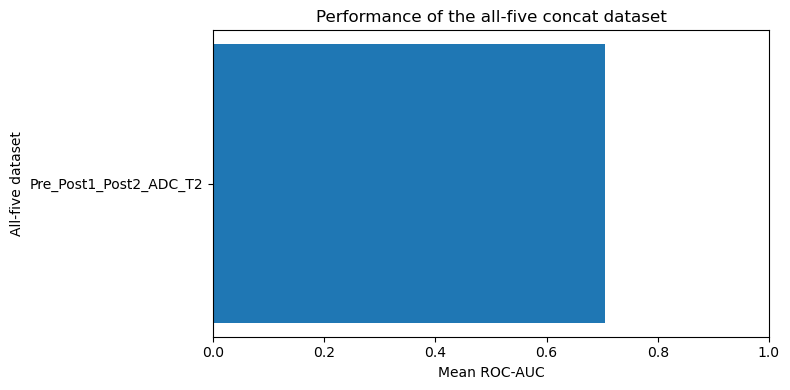

Plot saved:
batch_all_5_concat_runner_artifacts_smote_compare/summary_tables/all_5_mean_auc_barplot.png


In [8]:
# =============================================================================
# CELL 8 — PUBLICATION-STYLE COMPACT TABLE AND OPTIONAL PLOT
# =============================================================================

publication_cols = [
    "All5_Tag",
    "Dataset_A",
    "Dataset_B",
    "Dataset_C",
    "Dataset_D",
    "Dataset_E",
    "Rows_After_Merge",
    "N_Features_Total",
    "Label_Counts",
    "FS_METHOD",
    "FS_N_FEATURES",
    "USE_SMOTE",
    "Model",
    "Mean_AUC",
    "Std_AUC",
    "Pooled_AUC",
    "Mean_PR_AUC",
    "Pooled_PR_AUC",
    "Mean_Bal_Acc",
    "Pooled_Bal_Acc",
    "Mean_F1",
    "Pooled_F1",
    "Avg_Features",
    "N_Unique_Selected_Features",
    "Run_Name",
    "Run_Dir",
    "Final_Status",
    "Result_Error",
]

available_publication_cols = [c for c in publication_cols if c in df_all_5_summary.columns]
df_publication_all5 = df_all_5_summary[available_publication_cols].copy()

publication_path = SUMMARY_DIR / "publication_all_5_concat_summary.csv"
df_publication_all5.to_csv(publication_path, index=False)

print("Publication-style summary saved:")
print(publication_path)

display(df_publication_all5)


# Publication-style SMOTE delta table
if "df_all5_smote_vs_no_smote_best" in globals() and len(df_all5_smote_vs_no_smote_best) > 0:
    delta_publication_cols = [
        "All5_Tag",
        "Dataset_A",
        "Dataset_B",
        "Dataset_C",
        "Dataset_D",
        "Dataset_E",
        "Experiment_ID",
        "FS_METHOD",
        "Best_Model_No_SMOTE",
        "Best_Model_SMOTE",
        "Mean_AUC_No_SMOTE",
        "Mean_AUC_SMOTE",
        "Delta_Mean_AUC_SMOTE_minus_No_SMOTE",
        "Pooled_AUC_No_SMOTE",
        "Pooled_AUC_SMOTE",
        "Delta_Pooled_AUC_SMOTE_minus_No_SMOTE",
        "Mean_PR_AUC_No_SMOTE",
        "Mean_PR_AUC_SMOTE",
        "Delta_Mean_PR_AUC_SMOTE_minus_No_SMOTE",
        "Mean_Bal_Acc_No_SMOTE",
        "Mean_Bal_Acc_SMOTE",
        "Delta_Mean_Bal_Acc_SMOTE_minus_No_SMOTE",
        "Avg_Features_No_SMOTE",
        "Avg_Features_SMOTE",
        "Run_Name_No_SMOTE",
        "Run_Name_SMOTE",
    ]
    delta_publication_cols = [
        c for c in delta_publication_cols
        if c in df_all5_smote_vs_no_smote_best.columns
    ]
    df_publication_smote_delta = df_all5_smote_vs_no_smote_best[delta_publication_cols].copy()

    delta_publication_path = SUMMARY_DIR / "publication_all_5_smote_vs_no_smote_summary.csv"
    df_publication_smote_delta.to_csv(delta_publication_path, index=False)

    print("Publication-style SMOTE vs no-SMOTE summary saved:")
    print(delta_publication_path)
    display(df_publication_smote_delta)


# Optional simple plot of Mean_AUC for the all-five concat dataset.
try:
    import matplotlib.pyplot as plt

    plot_df = df_publication_all5.copy()
    plot_df["Mean_AUC_numeric"] = pd.to_numeric(plot_df.get("Mean_AUC"), errors="coerce")
    plot_df = plot_df.dropna(subset=["Mean_AUC_numeric"]).sort_values("Mean_AUC_numeric", ascending=True)

    if len(plot_df) > 0:
        fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(plot_df))))
        ax.barh(plot_df["All5_Tag"], plot_df["Mean_AUC_numeric"])
        ax.set_xlabel("Mean ROC-AUC")
        ax.set_ylabel("All-five dataset")
        ax.set_title("Performance of the all-five concat dataset")
        ax.set_xlim(0, 1)
        plt.tight_layout()

        plot_path = SUMMARY_DIR / "all_5_mean_auc_barplot.png"
        fig.savefig(plot_path, dpi=300, bbox_inches="tight")
        plt.show()

        print("Plot saved:")
        print(plot_path)

except Exception as e:
    print("Plot skipped:", e)